# Importação de Pacotes

In [2]:
#leitura da base de dados
import pandas as pd
from pathlib import Path
import parquet

#modelos preditivos escolhidos
import catboost as cb
from catboost import CatBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier

#validação cruzada
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, HalvingGridSearchCV
import numpy as np

#métricas
import matplotlib
from sklearn.metrics import accuracy_score, f1_score, recall_score, roc_auc_score, ConfusionMatrixDisplay, classification_report

#pipelines
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.utils.class_weight import compute_sample_weight

In [3]:
def estimadores(modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)

    acuracia = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    roc_auc = roc_auc_score(
        y_test,
        y_proba,
        multi_class='ovr',
        average='weighted'
    )

    ConfusionMatrixDisplay.from_estimator(modelo, X_test, y_test)

    print(f"""
        Acurácia: {acuracia:.3f}
        Recall (weighted): {recall:.3f}
        F1-score (weighted): {f1:.3f}
        ROC AUC (ovr): {roc_auc:.3f}
        """)

    print(classification_report(y_test, y_pred))

## Leitura DataFrame

In [4]:
direcao = Path("../..") / "data"
caminho = direcao / "erro_medico_tidy_final.parquet"


df_erro_simples = pd.read_parquet(caminho)

df = df_erro_simples

In [4]:
df.head(2)

,n_processo,escopo,data_de_disponibilizacao,decisao,morais_ped,morais_rec,materiais_ped,materiais_rec,classe,assunto,...,tem_hospital,tem_plano_saude,tem_ente_publico,tem_medico_individual,n_adv_autor,n_adv_reu,tem_perito,tem_denuncia_lide,tem_assistente,resumo_caso
0,10169222220248260564,sim,2026-02-24,proced,100000.0,55000.0,-1.0,-1.0,Procedimento Comum Cível,Serviços de Saúde,...,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,## Identificação do Caso\n- Número do processo...
1,10003518420258260355,sim,2026-02-23,improced,151800.0,0.0,75900.0,0.0,Procedimento Comum Cível,Serviços de Saúde,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,## Identificação do Caso\n- **Número do proces...


In [5]:
df.columns

Index(['n_processo', 'escopo', 'data_de_disponibilizacao', 'decisao',
       'morais_ped', 'morais_rec', 'materiais_ped', 'materiais_rec', 'classe',
       'assunto', 'foro', 'vara', 'juiz', 'data_distribuicao', 'valor_acao',
       'area', 'n_autores', 'n_reus', 'tem_hospital', 'tem_plano_saude',
       'tem_ente_publico', 'tem_medico_individual', 'n_adv_autor', 'n_adv_reu',
       'tem_perito', 'tem_denuncia_lide', 'tem_assistente', 'resumo_caso'],
      dtype='object')

# Aplicação de Pipelines

### CBC

In [8]:
modelo= CatBoostClassifier(auto_class_weights='Balanced')

parametros = {
    'modelo__iterations': [300],
    'modelo__depth': [4, 6],
    'modelo__learning_rate': [0.05, 0.1],
    'modelo__verbose': [0]
}

In [9]:
stopwords = ['a', 'à', 'o', 'e', 'de', 'do', 'da', 'em', 'um', 'uma', 'para', 'por', 'com', 
            'não', 'que', 'é', 'são', 'se', 'na', 'no', 'ao', 'como', 'mais', 'mas', 'ou',
            'ao', 'até', 'pela', 'pelas', 'pelo', 'pelos', 'nos', 'nas', 'deles', 'dela',
            'ele', 'ela', 'eles', 'elas', 'você', 'vocês', 'nós', 'eu', 'isso', 'isto',
            'aos', 'das', 'dos', 'esse', 'essa', 'esses', 'essas', 'aquele', 'aquela']


stopwords_jur = ['autor', 'réu', 'reu', 'partes', 'processo', 'autos', 'ação', 'acao',
                'decisão', 'decisao', 'sentença', 'sentenca', 'acórdão', 'acordao',
                'juiz', 'juízo', 'juizo', 'tribunal', 'vara', 'comarca','relator', 'relatora', 
                'ministro', 'ministra', 'requerente', 'requerido', 'requerida', 'apelante', 'apelado',
                'apelada', 'impetrante', 'impetrado', 'agravante', 'agravado', 'petição', 'peticao', 
                'inicial', 'contestação', 'contestacao', 'recurso', 'fundamentação', 'fundamentacao',
                'dispositivo', 'ementa', 'direito', 'fato', 'fatos', 'termos', 'forma', 'caso', 'art', 'artigo', 
                'lei', 'código', 'codigo', 'inciso', 'parágrafo', 'paragrafo', 'caput', 'diante', 'face', 'ante',
                'presente', 'autos', 'mesmos','bem', 'assim', 'ainda', 'conforme', 'respectivamente','visto', 
                'vista', 'decide', 'julgo', 'julgar', 'julga']

conjunto_stop_words = stopwords + stopwords

lista_X = ['valor_acao','n_autores', 'n_reus', 'tem_hospital', 'tem_plano_saude',
           'tem_ente_publico', 'tem_medico_individual', 'n_adv_autor', 'n_adv_reu',
           'tem_perito', 'tem_denuncia_lide', 'tem_assistente', 'resumo_caso']

X = df[lista_X]

y = df["decisao"]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=22)

tokenizer = Pipeline([
    ('token', TfidfVectorizer(
        max_features=10000, 
        ngram_range=(1, 2),
        stop_words= conjunto_stop_words,
        sublinear_tf=True))])

preprocessor = ColumnTransformer(
    transformers=[
        ('tokenizer', tokenizer, "resumo_caso")],
        remainder='passthrough')

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('modelo', modelo)
    ])

searchCV_pipeline = RandomizedSearchCV(
    pipeline,
    parametros,
    scoring='f1_macro',
    refit= True,
    cv=5,
    verbose=2
)

searchCV_pipeline.fit(X_train, y_train)

c:\Users\peper\OneDrive\Documentos\PIBIC\.venv\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=10. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV] END modelo__depth=4, modelo__iterations=300, modelo__learning_rate=0.05, modelo__verbose=0; total time=  57.1s
[CV] END modelo__depth=4, modelo__iterations=300, modelo__learning_rate=0.05, modelo__verbose=0; total time= 1.0min
[CV] END modelo__depth=4, modelo__iterations=300, modelo__learning_rate=0.05, modelo__verbose=0; total time= 1.2min
[CV] END modelo__depth=4, modelo__iterations=300, modelo__learning_rate=0.05, modelo__verbose=0; total time= 1.2min
[CV] END modelo__depth=4, modelo__iterations=300, modelo__learning_rate=0.05, modelo__verbose=0; total time= 1.2min
[CV] END modelo__depth=4, modelo__iterations=300, modelo__learning_rate=0.1, modelo__verbose=0; total time= 1.2min
[CV] END modelo__depth=4, modelo__iterations=300, modelo__learning_rate=0.1, modelo__verbose=0; total time= 1.2min
[CV] END modelo__depth=4, modelo__iterations=300, modelo__learning_rate=0.1, modelo__verbose=0; total time= 1.2min
[CV] END modelo

,estimator,Pipeline(step...'Balanced'))])
,param_distributions,"{'modelo__depth': [4, 6], 'modelo__iterations': [300], 'modelo__learning_rate': [0.05, 0.1], 'modelo__verbose': [0]}"
,n_iter,10
,scoring,'f1_macro'
,n_jobs,None
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan



        Acurácia: 0.590
        Recall (weighted): 0.590
        F1-score (weighted): 0.594
        ROC AUC (ovr): 0.632
        
              precision    recall  f1-score   support

    improced       0.74      0.70      0.72       420
 parc_proced       0.32      0.46      0.38       123
      proced       0.31      0.18      0.23        72

    accuracy                           0.59       615
   macro avg       0.46      0.45      0.44       615
weighted avg       0.61      0.59      0.59       615



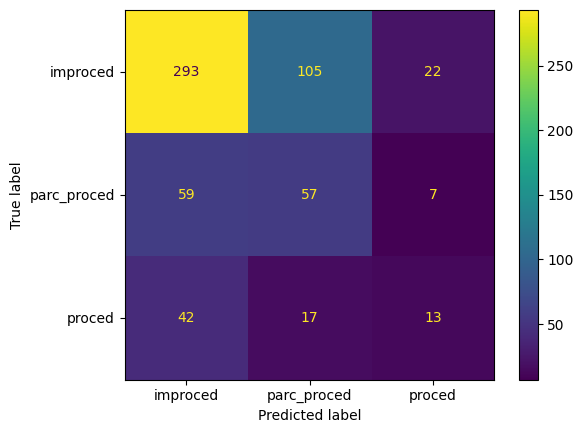

In [10]:
estimadores(searchCV_pipeline, X_test, y_test)

### GBC

In [ ]:
modelo= GradientBoostingClassifier()

parametros = {
    'modelo__n_estimators': [100],
    'modelo__max_depth': [2, 6],
    'modelo__max_leaf_nodes': [10],
    'modelo__learning_rate': [0.05, 0.2]
    }

In [ ]:
stopwords = ['a', 'à', 'o', 'e', 'de', 'do', 'da', 'em', 'um', 'uma', 'para', 'por', 'com', 
            'não', 'que', 'é', 'são', 'se', 'na', 'no', 'ao', 'como', 'mais', 'mas', 'ou',
            'ao', 'até', 'pela', 'pelas', 'pelo', 'pelos', 'nos', 'nas', 'deles', 'dela',
            'ele', 'ela', 'eles', 'elas', 'você', 'vocês', 'nós', 'eu', 'isso', 'isto',
            'aos', 'das', 'dos', 'esse', 'essa', 'esses', 'essas', 'aquele', 'aquela']



lista_X = ['valor_acao','n_autores', 'n_reus', 'tem_hospital', 'tem_plano_saude',
           'tem_ente_publico', 'tem_medico_individual', 'n_adv_autor', 'n_adv_reu',
           'tem_perito', 'tem_denuncia_lide', 'tem_assistente', 'resumo_caso']

X = df[lista_X]

y = df["decisao"]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=22)


tokenizer = Pipeline([
    ('token', TfidfVectorizer(
        max_features=10000, 
        ngram_range=(1, 2),
        stop_words= stopwords,
        sublinear_tf=True))])


num_prep = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_prep, ["valor_acao"]),
        ('tokenizer', tokenizer, "resumo_caso")], 
        remainder='passthrough')

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('modelo', modelo)
    ])

searchCV_pipeline = RandomizedSearchCV(
    pipeline,
    parametros,
    scoring='roc_auc_ovr',
    refit= True,
    cv=5,
    verbose=2
)

# balanceamento por sample_weight (GradientBoostingClassifier não aceita class_weight)
sample_weight = compute_sample_weight('balanced', y_train)
searchCV_pipeline.fit(X_train, y_train, modelo__sample_weight=sample_weight)


        Acurácia: 0.589
        Recall (weighted): 0.589
        F1-score (weighted): 0.572
        ROC AUC (ovr): 0.564
        
              precision    recall  f1-score   support

    improced       0.71      0.76      0.73       420
 parc_proced       0.29      0.29      0.29       123
      proced       0.16      0.08      0.11        72

    accuracy                           0.59       615
   macro avg       0.38      0.38      0.38       615
weighted avg       0.56      0.59      0.57       615



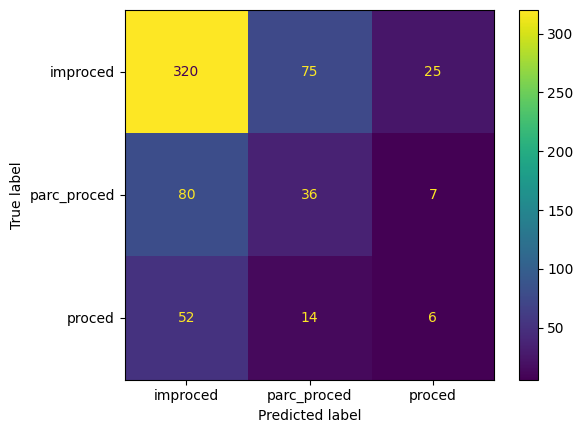

In [7]:
estimadores(searchCV_pipeline, X_test, y_test)

# Análise SHAP

PermutationExplainer explainer: 101it [00:42,  2.12it/s]                         
C:\Users\peper\AppData\Local\Temp\ipykernel_14380\913194223.py:56: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values.values, X_exp, feature_names=top_feature_names)


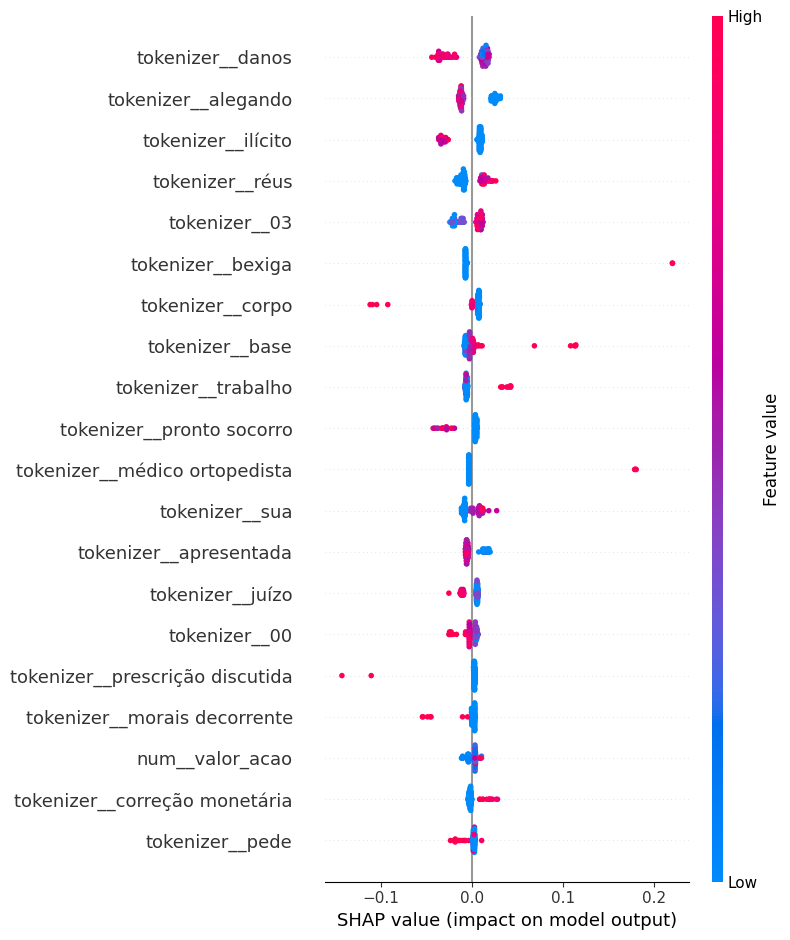

In [11]:
import shap
import numpy as np
from scipy import sparse

best_pipeline = searchCV_pipeline.best_estimator_

best_model = best_pipeline.named_steps["modelo"]
preprocessor = best_pipeline.named_steps["preprocessor"]

# transforma os dados
X_train_t = preprocessor.transform(X_train)
X_test_t = preprocessor.transform(X_test)

# converte para dense
X_train_dense = X_train_t.toarray() if sparse.issparse(X_train_t) else X_train_t
X_test_dense  = X_test_t.toarray() if sparse.issparse(X_test_t) else X_test_t

# nomes das features do pipeline transformado
feature_names = preprocessor.get_feature_names_out()

# pega importância do próprio modelo
importances = best_model.feature_importances_

# escolhe apenas as top N features
top_n = 30
top_idx = np.argsort(importances)[-top_n:][::-1]
top_feature_names = feature_names[top_idx]

# reduz os dados só para essas colunas
X_train_red = X_train_dense[:, top_idx]
X_test_red  = X_test_dense[:, top_idx]

# classe que você quer explicar
classe_idx = 0  # troque para 1, 2, etc. se quiser outra classe

# função que recebe só as top features e reconstrói a entrada completa
def predict_class_prob(X_red):
    X_full = np.zeros((X_red.shape[0], X_train_dense.shape[1]))
    X_full[:, top_idx] = X_red
    return best_model.predict_proba(X_full)[:, classe_idx]

# background pequeno
background = shap.sample(X_train_red, 100, random_state=22)

explainer = shap.Explainer(
    predict_class_prob,
    background,
    algorithm="permutation",
    feature_names=top_feature_names
)

# explica um subconjunto
X_exp = X_test_red[:100]
shap_values = explainer(X_exp, max_evals=2 * top_n + 1)

shap.summary_plot(shap_values.values, X_exp, feature_names=top_feature_names)